In [1]:
# Librerías básicas para análisis de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Configuración básica de gráficos
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

In [2]:
# Cargar la base de datos
df = pd.read_csv("bd.csv")

# Mostrar las primeras filas
df.head()

,X,Y,Z,Fe,Si,P,Al,Mn,Rocktype
0,-7400.22,1496.58,1457.62,46.478,31.620,0.017,1.139,0.01,7
1,-7400.22,1496.58,1450.37,40.578,40.838,0.028,0.711,0.01,7
2,-7400.22,1496.58,1427.72,40.488,40.655,0.012,0.914,0.01,6
3,-7400.22,1496.58,1421.62,40.488,40.655,0.012,0.914,0.01,6
4,-7400.22,1496.58,1415.52,43.969,35.776,0.017,0.854,0.01,7


In [3]:
df.describe()

,X,Y,Z,Fe,Si,P,Al,Mn,Rocktype
count,4463.000000,4463.000000,4463.000000,4463.000000,4463.000000,4463.000000,4463.000000,4463.000000,4463.000000
mean,-6413.982059,1389.103876,1321.784248,51.757401,21.781310,0.054760,1.309315,0.300476,2.480842
std,538.271579,190.878227,85.876086,11.574603,17.417562,0.040945,1.288902,1.392046,18.300557
min,-7501.240000,902.280000,1025.580000,9.916000,0.216000,0.007000,0.100000,0.008000,-99.000000
25%,-6799.990000,1258.585000,1276.275000,42.412500,4.305000,0.027000,0.457000,0.014000,3.000000
50%,-6355.430000,1384.080000,1335.060000,52.934000,20.228000,0.044000,0.913000,0.031000,7.000000
75%,-6000.000000,1506.005000,1379.050000,62.256000,36.496000,0.071000,1.714000,0.085500,7.000000
max,-5386.290000,1935.910000,1517.900000,69.701000,77.045000,0.530000,12.599000,32.057000,10.000000


In [4]:
# Ver tipos de datos de cada columna
df.dtypes

X           float64
Y           float64
Z           float64
Fe          float64
Si          float64
P           float64
Al          float64
Mn          float64
Rocktype      int64
dtype: object

In [5]:
# Información general de la base de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4463 entries, 0 to 4462
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   X         4463 non-null   float64
 1   Y         4463 non-null   float64
 2   Z         4463 non-null   float64
 3   Fe        4463 non-null   float64
 4   Si        4463 non-null   float64
 5   P         4463 non-null   float64
 6   Al        4463 non-null   float64
 7   Mn        4463 non-null   float64
 8   Rocktype  4463 non-null   int64  
dtypes: float64(8), int64(1)
memory usage: 313.9 KB


In [6]:
# Dimensión de la base de datos
print("Número de filas:", df.shape[0])
print("Número de columnas:", df.shape[1])

Número de filas: 4463
Número de columnas: 9


In [7]:
# Cantidad de valores nulos por columna
df.isnull().sum()

X           0
Y           0
Z           0
Fe          0
Si          0
P           0
Al          0
Mn          0
Rocktype    0
dtype: int64

In [8]:
# Variables químicas a analizar
variables_quimicas = ["Fe", "Si", "P", "Al", "Mn"]

# Estadísticos básicos
df[variables_quimicas].describe()

,Fe,Si,P,Al,Mn
count,4463.000000,4463.000000,4463.000000,4463.000000,4463.000000
mean,51.757401,21.781310,0.054760,1.309315,0.300476
std,11.574603,17.417562,0.040945,1.288902,1.392046
min,9.916000,0.216000,0.007000,0.100000,0.008000
25%,42.412500,4.305000,0.027000,0.457000,0.014000
50%,52.934000,20.228000,0.044000,0.913000,0.031000
75%,62.256000,36.496000,0.071000,1.714000,0.085500
max,69.701000,77.045000,0.530000,12.599000,32.057000


In [9]:
# Estadísticos específicos
estadisticos = df[variables_quimicas].agg(["mean", "min", "max", "std", "median"])

estadisticos

,Fe,Si,P,Al,Mn
mean,51.757401,21.781310,0.054760,1.309315,0.300476
min,9.916000,0.216000,0.007000,0.100000,0.008000
max,69.701000,77.045000,0.530000,12.599000,32.057000
std,11.574603,17.417562,0.040945,1.288902,1.392046
median,52.934000,20.228000,0.044000,0.913000,0.031000


In [10]:
# Diferencia entre valor máximo y mínimo de Fe
diferencia_Fe = df["Fe"].max() - df["Fe"].min()

print("Diferencia entre máximo y mínimo de Fe:", diferencia_Fe)

Diferencia entre máximo y mínimo de Fe: 59.785


In [11]:
# Calcular percentiles 33 y 66 para Fe
P33_Fe = df["Fe"].quantile(0.33)
P66_Fe = df["Fe"].quantile(0.66)

print("Percentil 33 de Fe:", P33_Fe)
print("Percentil 66 de Fe:", P66_Fe)

Percentil 33 de Fe: 45.27846
Percentil 66 de Fe: 59.26352000000001


In [12]:
# Función condicional para clasificar Fe
def clasificar_Fe(valor):
    if valor < P33_Fe:
        return "Fe bajo"
    elif valor <= P66_Fe:
        return "Fe medio"
    else:
        return "Fe alto"

# Crear nueva columna con la clasificación de Fe
df["Clasificacion_Fe"] = df["Fe"].apply(clasificar_Fe)

# Mostrar resultados
df[["Fe", "Clasificacion_Fe"]].head()

,Fe,Clasificacion_Fe
0,46.478,Fe medio
1,40.578,Fe bajo
2,40.488,Fe bajo
3,40.488,Fe bajo
4,43.969,Fe bajo


In [13]:
# Conteo por categoría de Fe
df["Clasificacion_Fe"].value_counts()

Clasificacion_Fe
Fe alto     1518
Fe bajo     1473
Fe medio    1472
Name: count, dtype: int64

In [14]:
# Recorrer variables químicas y mostrar estadísticos principales
for variable in variables_quimicas:
    print("Variable:", variable)
    print("Promedio:", df[variable].mean())
    print("Mínimo:", df[variable].min())
    print("Máximo:", df[variable].max())
    print("Desviación estándar:", df[variable].std())
    print("-" * 40)

Variable: Fe
Promedio: 51.75740062738069
Mínimo: 9.916
Máximo: 69.701
Desviación estándar: 11.57460306829709
----------------------------------------
Variable: Si
Promedio: 21.7813098812458
Mínimo: 0.216
Máximo: 77.045
Desviación estándar: 17.41756179480751
----------------------------------------
Variable: P
Promedio: 0.054760250952274256
Mínimo: 0.007
Máximo: 0.53
Desviación estándar: 0.040944894882875595
----------------------------------------
Variable: Al
Promedio: 1.3093150347300022
Mínimo: 0.1
Máximo: 12.599
Desviación estándar: 1.2889021124776505
----------------------------------------
Variable: Mn
Promedio: 0.30047636119202326
Mínimo: 0.008
Máximo: 32.057
Desviación estándar: 1.3920458330663286
----------------------------------------


In [15]:
# Función para obtener resumen estadístico de una variable química
def resumen_estadistico(variable):
    resumen = {
        "Variable": variable,
        "Promedio": df[variable].mean(),
        "Mínimo": df[variable].min(),
        "Máximo": df[variable].max(),
        "Mediana": df[variable].median(),
        "Desviación estándar": df[variable].std(),
        "Percentil 33": df[variable].quantile(0.33),
        "Percentil 66": df[variable].quantile(0.66)
    }
    return pd.DataFrame([resumen])

In [16]:
# Aplicar función para Fe
resumen_estadistico("Fe")

,Variable,Promedio,Mínimo,Máximo,Mediana,Desviación estándar,Percentil 33,Percentil 66
0,Fe,51.757401,9.916,69.701,52.934,11.574603,45.27846,59.26352


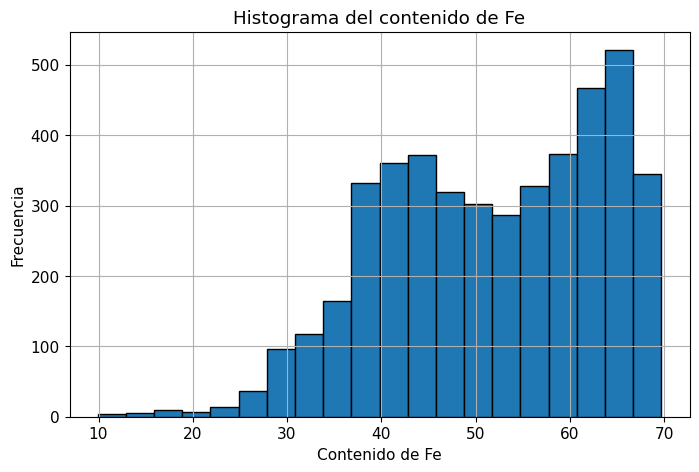

In [17]:
plt.figure()

plt.hist(df["Fe"], bins=20, edgecolor="black")

plt.title("Histograma del contenido de Fe")
plt.xlabel("Contenido de Fe")
plt.ylabel("Frecuencia")

plt.show()

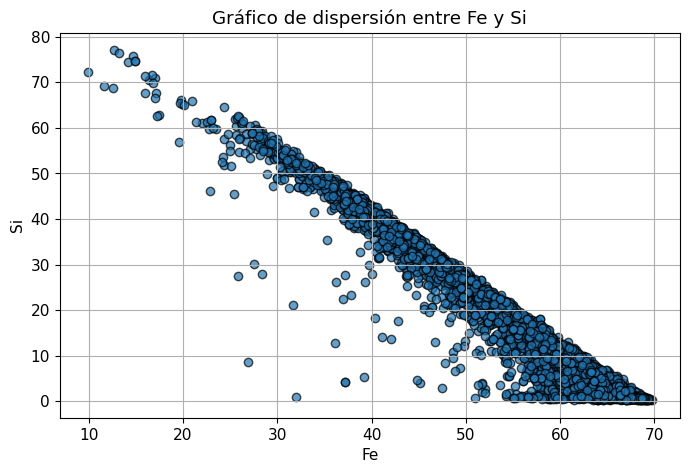

In [18]:
plt.figure()

plt.scatter(df["Fe"], df["Si"], alpha=0.7, edgecolor="black")

plt.title("Gráfico de dispersión entre Fe y Si")
plt.xlabel("Fe")
plt.ylabel("Si")

plt.show()

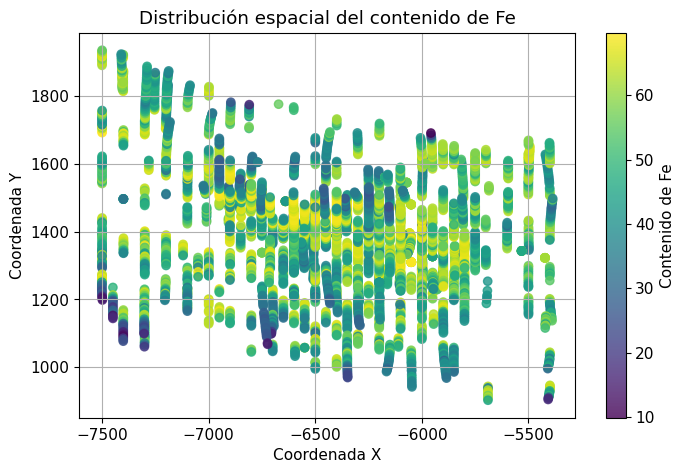

In [19]:
plt.figure()

plt.scatter(df["X"], df["Y"], c=df["Fe"], alpha=0.8)

plt.colorbar(label="Contenido de Fe")

plt.title("Distribución espacial del contenido de Fe")
plt.xlabel("Coordenada X")
plt.ylabel("Coordenada Y")

plt.show()